In [ ]:
!pip install -U gdown ultralytics scikit-learn albumentations -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 53.8 MB/s eta 0:00:00


## 0. Download dataset

In [ ]:
# # Download License_Plates_VietNam dataset
# # https://drive.google.com/file/d/1waSF8HVKari79-Uhil8wy87RZxjHpUE3/view
!gdown 1waSF8HVKari79-Uhil8wy87RZxjHpUE3
!unzip -q License_Plates_VietNam.zip -d datasets

Downloading...
From (original): https://drive.google.com/uc?id=1waSF8HVKari79-Uhil8wy87RZxjHpUE3
From (redirected): https://drive.google.com/uc?id=1waSF8HVKari79-Uhil8wy87RZxjHpUE3&confirm=t&uuid=58ddbdb6-ed3c-4cfd-89ff-e09c9d592adf
To: /content/License_Plates_VietNam.zip
100% 218M/218M [00:03<00:00, 59.9MB/s]


## 1. Convert dataset (polygon) to BBOX Yolo format

In [ ]:
import os

base_dirs = [
    "datasets/train/labels",
    "datasets/valid/labels",
    "datasets/test/labels"
]

def convert_polygon_to_bbox(coords):
    xs = coords[0::2]
    ys = coords[1::2]

    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)

    x_center = (x_min + x_max) / 2
    y_center = (y_min + y_max) / 2
    width = x_max - x_min
    height = y_max - y_min

    return x_center, y_center, width, height

for label_dir in base_dirs:
    for file in os.listdir(label_dir):
        path = os.path.join(label_dir, file)

        new_lines = []

        with open(path, "r") as f:
            for line in f:
                parts = list(map(float, line.strip().split()))
                class_id = int(parts[0])
                coords = parts[1:]

                x, y, w, h = convert_polygon_to_bbox(coords)
                new_lines.append(f"{class_id} {x} {y} {w} {h}")

        with open(path, "w") as f:
            f.write("\n".join(new_lines))

print("Done converting all labels!")

Done converting all labels!


## 2. Import libraries

In [ ]:
# %pip install -q -U ultralytics

In [ ]:
import ultralytics

ultralytics.checks()

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 44.0/112.6 GB disk)


In [ ]:
# You can run this to check if the model is working
# !yolo predict model=yolo11n.pt source='https://ultralytics.com/images/bus.jpg'

##3. Train model

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo11n.pt")

# Train model
results = model.train(
    data="/content/datasets/data.yaml",
    epochs=50,
    imgsz=640,
    cache=True,
    patience=20,
    plots=True,
)

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0

## 4. Evaluation

In [ ]:
from ultralytics import YOLO

model_path = "runs/detect/train/weights/best.pt"
model = YOLO(model_path)

metrics = model.val()

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7.7±4.5 MB/s, size: 40.6 KB)
val: Scanning /content/datasets/valid/labels.cache... 1044 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1044/1044 364.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 66/66 5.5it/s 12.0s
                   all       1044       1212      0.988      0.985      0.993      0.911
   long-license-plates        357        358      0.997      0.992      0.993      0.908
  short-license-plates        704        854      0.979      0.978      0.993      0.913
Speed: 1.5ms preprocess, 4.2ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val


## 9. Inference

In [ ]:
import json

import cv2
import matplotlib.pyplot as plt


def visualize_bbox(
    img_path, predictions, conf_thres=0.8, font=cv2.FONT_HERSHEY_SIMPLEX
):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    for prediction in predictions:
        conf_score = prediction["confidence"]

        if conf_score < conf_thres:
            continue

        bbox = prediction["box"]
        xmin = int(bbox["x1"])
        ymin = int(bbox["y1"])
        xmax = int(bbox["x2"])
        ymax = int(bbox["y2"])

        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)

        text = f"{conf_score:.2f}"
        (text_width, text_height), _ = cv2.getTextSize(text, font, 1, 2)

        cv2.rectangle(
            img,
            (xmin, ymin - text_height - 5),
            (xmin + text_width, ymin),
            (0, 255, 0),
            -1,
        )
        cv2.putText(img, text, (xmin, ymin - 5), font, 1, (0, 0, 0), 2)

    return img

In [ ]:
!zip -r -q /content/runs.zip /content/runs
from google.colab import files
files.download('/content/runs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

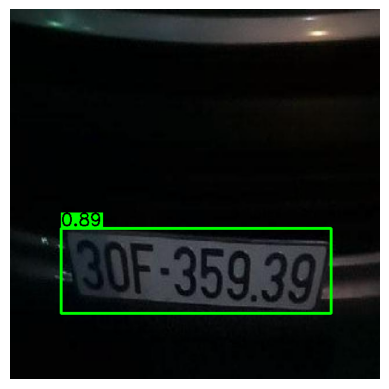

In [ ]:
from ultralytics import YOLO

model_path = "runs/detect/train/weights/best.pt"
img_path = "/content/datasets/test/images/Tgmt_0398_png.rf.056bbb889b887b27c8c446100f332a54.jpg"
conf_thres = 0.75
model = YOLO(model_path)

# Run inference
results = model(img_path, verbose=False)
predictions = json.loads(results[0].to_json())
visualized_img = visualize_bbox(img_path, predictions, conf_thres)

%matplotlib inline
plt.imshow(visualized_img)
plt.axis("off")
plt.show()